# Evaluating confidence predictor

Here, we evaluate our confidence prediction model and assess how well it matches to poorly predicted data points.

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as rt
import pandas as pd
import seaborn as sns
import torch

from tcr_antigen_prediction.models import TCRContactMapPredictor

In [2]:
with h5py.File('data/processed/nettcr.h5') as fh:
    cdr_1as = fh['cdr_1a'][:]
    cdr_2as = fh['cdr_2a'][:]
    cdr_3as = fh['cdr_3a'][:]
    cdr_1bs = fh['cdr_1b'][:]
    cdr_2bs = fh['cdr_2b'][:]
    cdr_3bs = fh['cdr_3b'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo_sequence'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

results = pd.DataFrame(
    {
        'cdr_1a': list(cdr_1as),
        'cdr_2a': list(cdr_2as),
        'cdr_3a': list(cdr_3as),
        'cdr_1b': list(cdr_1bs),
        'cdr_2b': list(cdr_2bs),
        'cdr_3b': list(cdr_3bs),
        'peptide': list(peptides),
        'mhc': list(mhcs),
        'fold': folds,
        'label': labels,
    }
)

In [3]:
tcr_pmhcs = np.concatenate([cdr_1as, cdr_2as, cdr_3as, cdr_1bs, cdr_2bs, cdr_3bs, peptides, mhcs], axis=1)
tcr_pmhcs_flat = tcr_pmhcs.reshape(tcr_pmhcs.shape[0], -1)

In [4]:
fold_results = []
for fold_num in range(1, 5 + 1):
    fold_predictions = results.copy()
    model = TCRContactMapPredictor()
    model.load_state_dict(
        torch.load(
            f'models/TCRContactMapPredictor/model_{fold_num}.pt',
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )
    model.eval()

    predictions = model(
        torch.tensor(cdr_1as, dtype=torch.float32),
        torch.tensor(cdr_2as, dtype=torch.float32),
        torch.tensor(cdr_3as, dtype=torch.float32),
        torch.tensor(cdr_1bs, dtype=torch.float32),
        torch.tensor(cdr_2bs, dtype=torch.float32),
        torch.tensor(cdr_3bs, dtype=torch.float32),
        torch.tensor(peptides, dtype=torch.float32),
        torch.tensor(mhcs, dtype=torch.float32),
    )

    sess = rt.InferenceSession(f'models/ConfidencePredictor/model_{fold_num}.onnx')
    input_name = sess.get_inputs()[0].name
    label_name = sess.get_outputs()[0].name
    confidence, *_ = sess.run(None, {'X': tcr_pmhcs_flat.astype(np.float32)})

    fold_predictions['prediction'] = predictions.squeeze(-1).detach().cpu().numpy()
    fold_predictions['confidence'] = confidence.squeeze(-1)
    fold_predictions['holdout_fold'] = fold_num

    fold_results.append(fold_predictions)

results = pd.concat(fold_results).reset_index(drop=True)

2025-01-08 14:28:54.512775640 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 3510974, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-08 14:28:54.516704703 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 3510975, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-08 14:28:54.522970695 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 3510976, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-08 14:28:54.528033908 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 3510977, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the 

In [5]:
THRESHOLD = 0.5
results['prediction_binary'] = (results['prediction'] > THRESHOLD).apply(int)

In [6]:
results['residual_abs'] = np.abs(results['label'] - results['prediction'])

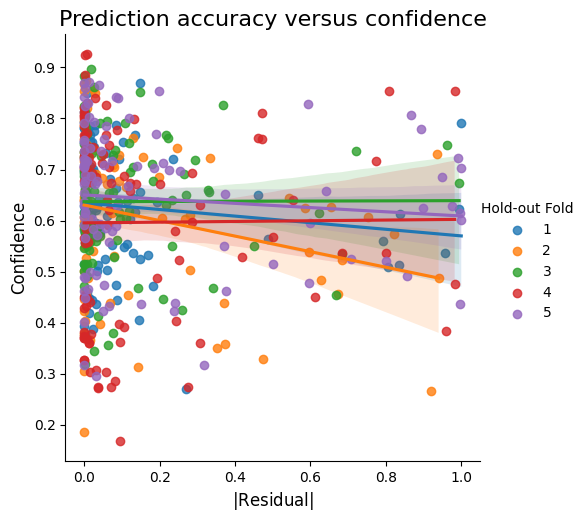

In [7]:
ax = sns.lmplot(results.sample(500), x='residual_abs', y='confidence', hue='holdout_fold')

plt.title('Prediction accuracy versus confidence', fontsize=16)
plt.xlabel(r'$|\text{Residual}|$', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

ax.legend.set_title('Hold-out Fold')

plt.show()

In [8]:
results['residual_squared'] = (results['label'] - results['prediction']) ** 2

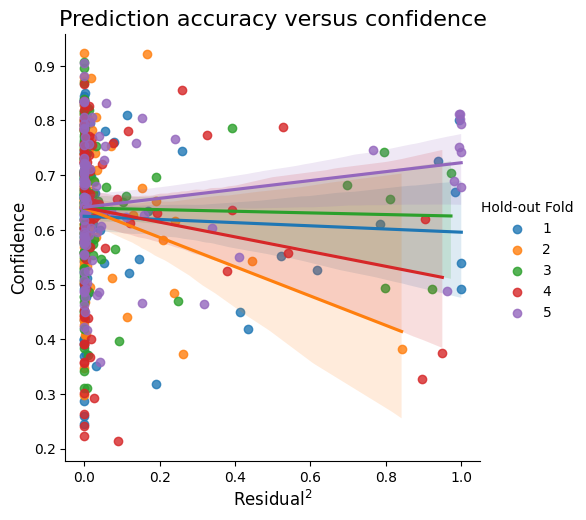

In [9]:
ax = sns.lmplot(results.sample(500), x='residual_squared', y='confidence', hue='holdout_fold')

plt.title('Prediction accuracy versus confidence', fontsize=16)
plt.xlabel(r'$\text{Residual}^2$', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

ax.legend.set_title('Hold-out Fold')

plt.show()